In [1]:
from openpiv import tools, pyprocess, validation, filters, scaling

import numpy as np
import matplotlib.pyplot as plt
%matplotlib inline
import io
from PIL import Image
from IPython.display import Image as IPyImage, display
from matplotlib.ticker import FuncFormatter
import matplotlib.pyplot as plt
import sys
sys.path.append('/Users/kjesta/Desktop/Master prosjekt/Master_code/Lab/PIV/')   
import xarray as xr
import imageio
import pathlib
import cmcrameri.cm as cm
import pandas as pd
from piv_func import perform_piv

import matplotlib.style as mplstyle
mplstyle.use(["ggplot", "fast"])

# Particle Image Velocimetry
#### Kjersti Stangeland, Spring 2026
**Analyzing**:
* f = 1.4 Hz
* A = 0.2 V
* D = 0.2 m
* H = 0.15 m

Run 3 out of 3

In [2]:
# Opening frames needed for analyzing two wave periods
ims = np.linspace(1250, 1516, 267)  # Adjusted to cover three periods (1250 to 1516)
frames = {}

for im in ims:
    im_int = int(im)
    img = tools.imread(f'/Users/kjesta/Desktop/LABDATA/PIV/f14a02/bitmap3/image_p{im_int}.bmp')
    frames[im_int] = img

In [3]:
T = 1/1.4  # wave period, seconds
fps = 125  # frames per second
dt = 1/fps  # time between frames, seconds
fpp = fps*T  # frames per period
images_needed = int(3*fpp)

print(f"Frames per period: {fpp:.2f}")
print(f"Time between frames: {dt:.4f} s")
print(f"Total images needed for three periods: {images_needed}")
print(f"Frames opened: {len(frames)}")

Frames per period: 89.29
Time between frames: 0.0080 s
Total images needed for three periods: 267
Frames opened: 267


In [4]:
timestamps = [i * dt + 10 for i in list(frames.keys())] # timestamps for one period, starting at 10 seconds

In [5]:
'''
Cutting out mid part of image. 
Want to avoid the free surface as the edge effects there
distort the velocity field.
I also match the indices to the reference photo to be sure the scaling is correct.
'''
y_min = 1080
y_max = 1490

x_min = 15
x_max = 1250

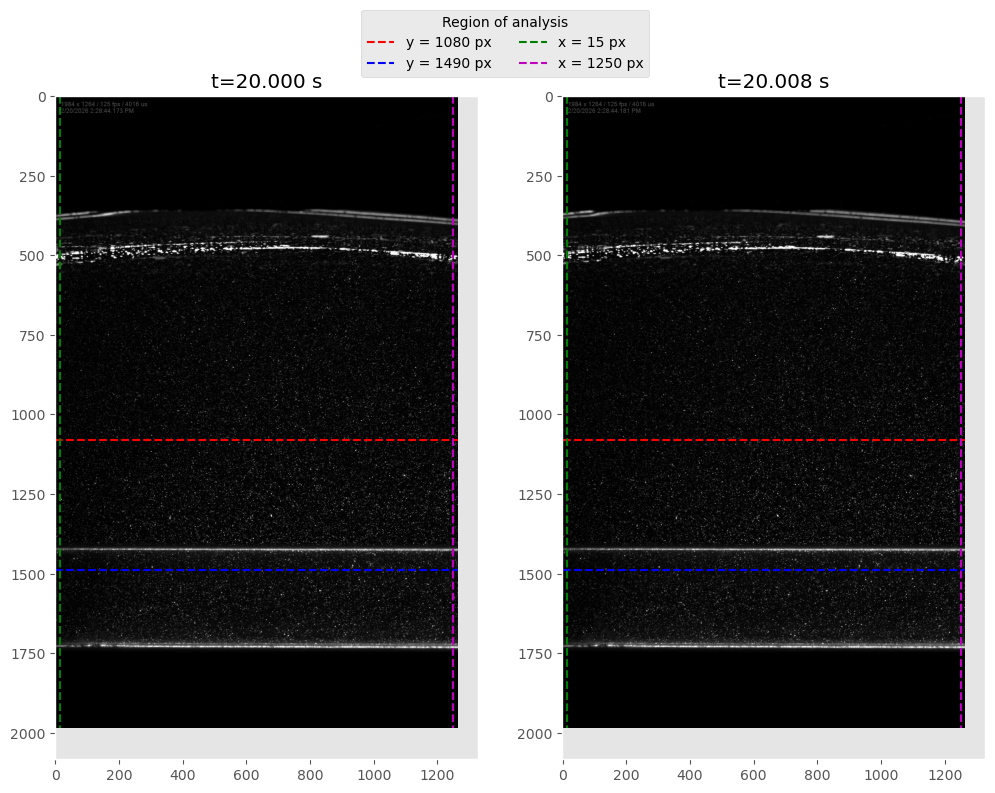

In [6]:
fig, ax =plt.subplots(1,2, figsize=(12,10))
ax[0].imshow(frames[1250], cmap='gray')
ax[0].hlines(y=y_min, xmin=0, xmax=frames[1250].shape[1], colors='r', linestyles='--', label=f'y = {y_min} px')
ax[0].hlines(y=y_max, xmin=0, xmax=frames[1250].shape[1], colors='b', linestyles='--', label=f'y = {y_max} px')
ax[0].vlines(x=x_min, ymin=0, ymax=frames[1250].shape[0], colors='g', linestyles='--', label=f'x = {x_min} px')
ax[0].vlines(x=x_max, ymin=0, ymax=frames[1250].shape[0], colors='m', linestyles='--', label=f'x = {x_max} px')
ax[0].set_title(f't={timestamps[0]:.3f} s')

ax[1].imshow(frames[1251], cmap='gray')
ax[1].set_title(f't={timestamps[1]:.3f} s')
ax[1].hlines(y=y_min, xmin=0, xmax=frames[1251].shape[1], colors='r', linestyles='--')
ax[1].hlines(y=y_max, xmin=0, xmax=frames[1251].shape[1], colors='b', linestyles='--')
ax[1].vlines(x=x_min, ymin=0, ymax=frames[1251].shape[0], colors='g', linestyles='--')
ax[1].vlines(x=x_max, ymin=0, ymax=frames[1251].shape[0], colors='m', linestyles='--')

ax[0].grid()
ax[1].grid()
fig.legend(title='Region of analysis', loc='upper center', bbox_to_anchor=(0.5, 0.92), ncol=2)

In [7]:
# Zoom in on area of interest
# Ignoring the surface and the bottom of the frame
zoom_frames = {}
for key in frames.keys():
    zoom_frames[key] = frames[key][y_min:y_max, x_min:x_max]

In [8]:
plate_top_index = 343

Text(0.5, 0.9, 'Raw, zoomed in, frames')

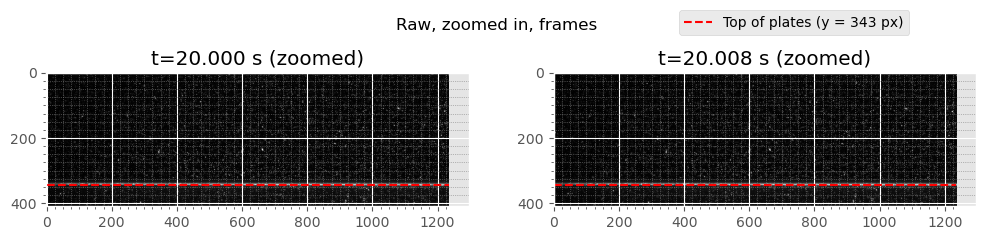

In [9]:
fig, ax =plt.subplots(1,2, figsize=(12,3))
ax[0].imshow(zoom_frames[1250], cmap='gray')
ax[0].set_title(f't={timestamps[0]:.3f} s (zoomed)')
ax[0].hlines(y=plate_top_index, xmin=0, xmax=zoom_frames[1250].shape[1], colors='r', linestyles='--', label=f'Top of plates (y = {plate_top_index} px)')

ax[1].imshow(zoom_frames[1251], cmap='gray')
ax[1].set_title(f't={timestamps[1]:.3f} s (zoomed)')
ax[1].hlines(y=plate_top_index, xmin=0, xmax=zoom_frames[1251].shape[1], colors='r', linestyles='--')

# add finer grid
ax[0].set_xticks(np.arange(0, zoom_frames[1250].shape[1], 25), minor=True)
ax[0].set_yticks(np.arange(0, zoom_frames[1250].shape[0], 25), minor=True)
ax[0].grid(which='minor', color='gray', linestyle=':', linewidth=0.5)
ax[1].set_xticks(np.arange(0, zoom_frames[1251].shape[1], 25), minor=True)
ax[1].set_yticks(np.arange(0, zoom_frames[1251].shape[0], 25), minor=True)
ax[1].grid(which='minor', color='gray', linestyle=':', linewidth=0.5)

fig.legend(loc='upper right', bbox_to_anchor=(0.85, 0.95), ncol=2)
fig.suptitle('Raw, zoomed in, frames', y=0.9)

In [10]:
# Load reference image
reference = tools.imread('/Users/kjesta/Desktop/LABDATA/PIV/reference_p29.bmp')

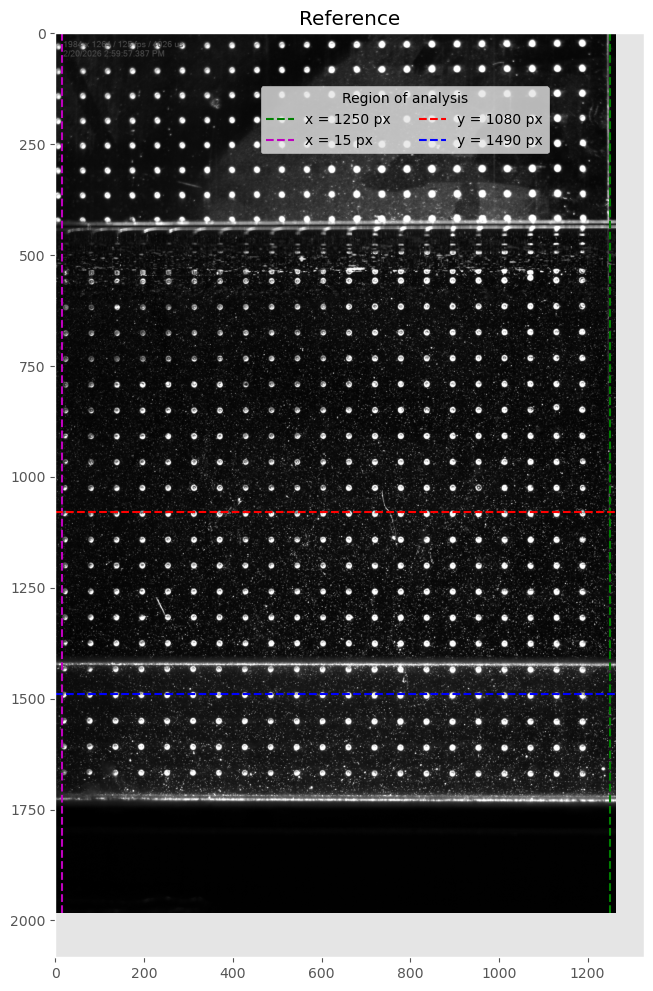

In [11]:
fig, ax =plt.subplots(1, figsize=(12, 12))
ax.imshow(reference, cmap='gray')
ax.vlines(x=x_max, ymin=0, ymax=reference.shape[0], colors='g', linestyles='--', label=f'x = {x_max} px')
ax.vlines(x=x_min, ymin=0, ymax=reference.shape[0], colors='m', linestyles='--', label=f'x = {x_min} px')
ax.hlines(y=y_min, xmin=0, xmax=reference.shape[1], colors='r', linestyles='--', label=f'y = {y_min} px')
ax.hlines(y=y_max, xmin=0, xmax=reference.shape[1], colors='b', linestyles='--', label=f'y = {y_max} px')
ax.legend(title='Region of analysis', loc='upper right', bbox_to_anchor=(0.85, 0.95), ncol=2)
ax.set_title('Reference')
ax.grid()

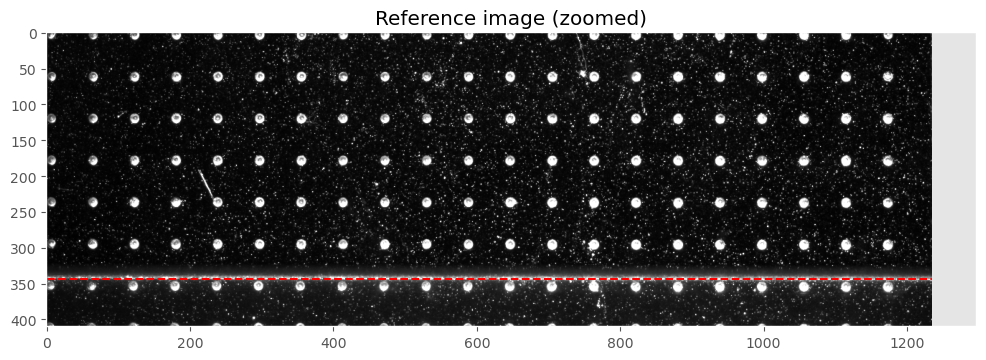

In [12]:
# Zoom in on reference image
reference_zoom = reference[y_min:y_max, x_min:x_max]

fig, ax =plt.subplots(1, figsize=(12,6))
ax.imshow(reference_zoom, cmap='gray')
ax.set_title('Reference image (zoomed)')
ax.hlines(y=plate_top_index, xmin=0, xmax=reference_zoom.shape[1], colors='r', linestyles='--')
ax.grid()

In [13]:
# Distance between pixel 15 and 1250 (in horizontal direction)
x_m = 0.21
# Distance between pixel 1250 and 1725 (in vertical direction)
y_m = 0.07

# Calculate pixel to m scaling factors
x_scale = (x_max - x_min) / x_m  # pixel per m
y_scale = (y_max - y_min) / y_m  # pixel per m

print(f"x_scale = {x_scale:.3f} px/m, y_scale = {y_scale:.3f} px/m")
print(f'Percentage difference: {(x_scale-y_scale)/y_scale * 100:.2f}%')

# Average if appropriate
scaling_factor = (x_scale + y_scale) / 2
print(f"Average scaling factor: {scaling_factor:.3f} px/m")

x_scale = 5880.952 px/m, y_scale = 5857.143 px/m
Percentage difference: 0.41%
Average scaling factor: 5869.048 px/m


In [14]:
# Crop frames to region of interest
ims = np.linspace(1250, 1516, 267)
cropped_frames = {}

for im in ims:
    cropped_frames[int(im)] = frames[int(im)][y_min:y_max, x_min:x_max]

In [15]:
# Removing static background
static = np.median(list(cropped_frames.values()), axis=0)
cleaned_frames = {}
for key in cropped_frames.keys():
    cleaned_frames[key] = cropped_frames[key] - static

In [16]:
def depth_formatter(y_tick, pos):
        # depth: negative downward
        # Adding ashift the depth values so that it matches real water depth
        return f"{-(y_tick + 0.09):.2f}"

def x_phys_formatter(x_tick, pos):
        # Map image x → physical x (paddle at 8.06 m on the right)
        return f"{8.06 + (x_max - x_tick):.2f}"

Window size: 32 px, Stepsize: 2
Displacement (x, y): (3, 2) pixels
Window size: 32 px, Stepsize: 3
Displacement (x, y): (5, 3) pixels
Window size: 32 px, Stepsize: 4
Displacement (x, y): (7, 4) pixels
Window size: 32 px, Stepsize: 5
Displacement (x, y): (9, 5) pixels


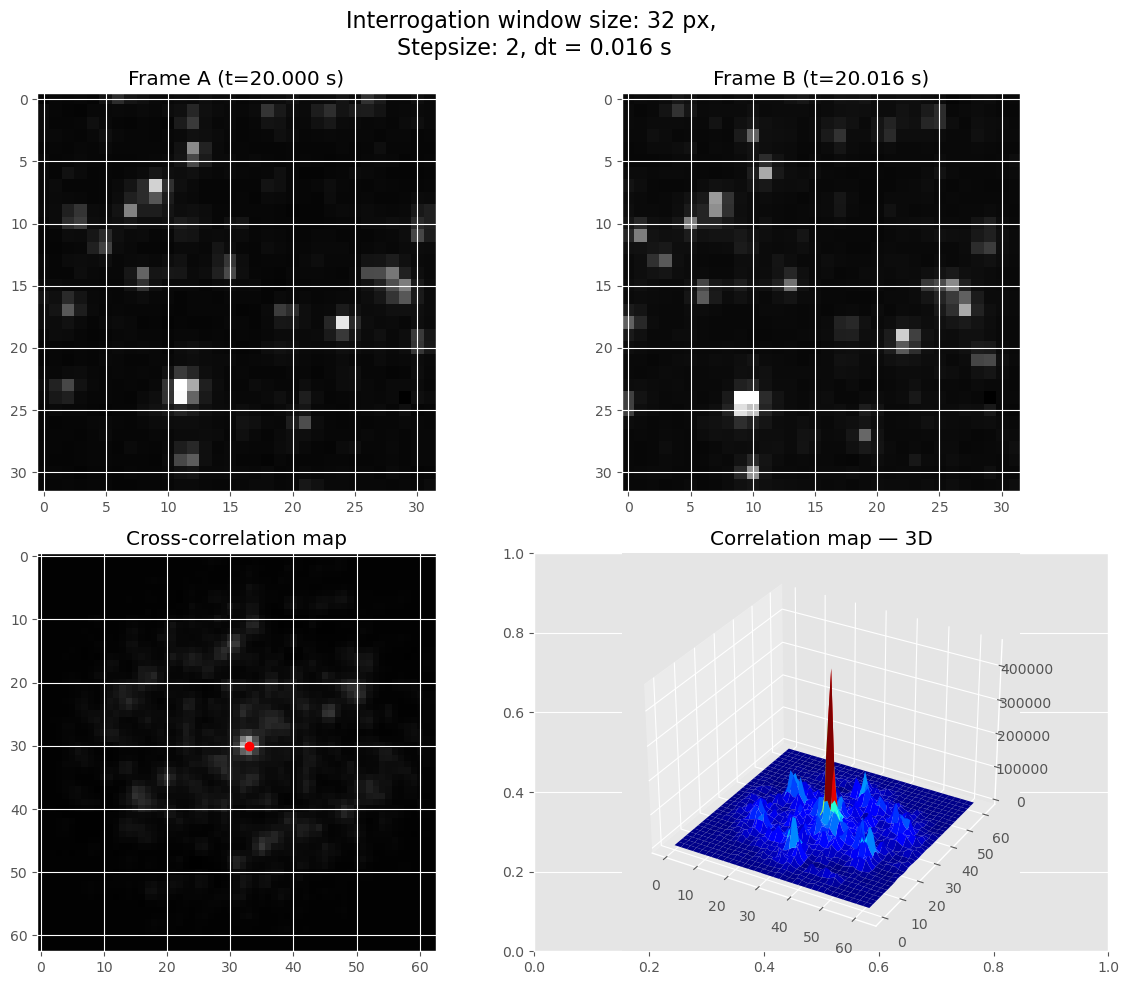

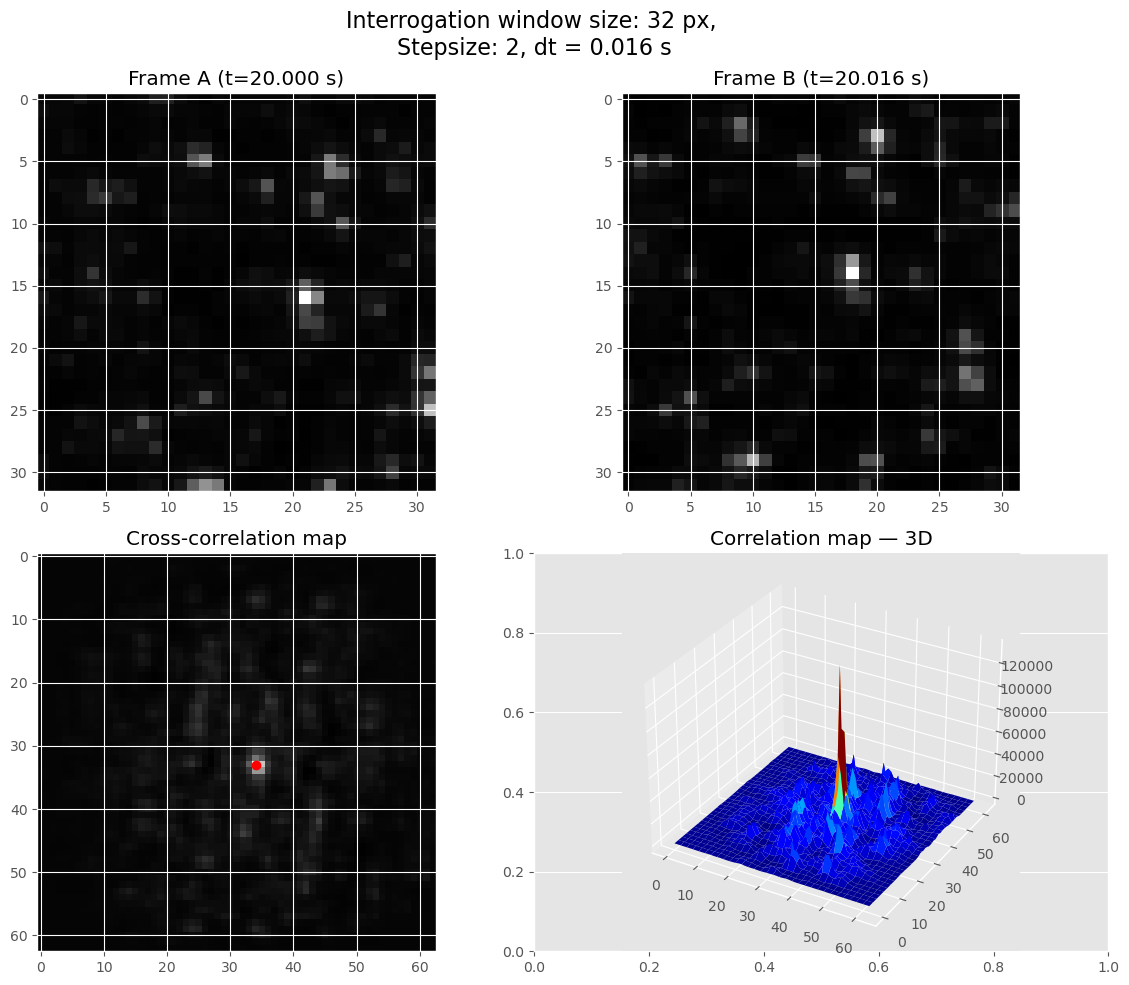

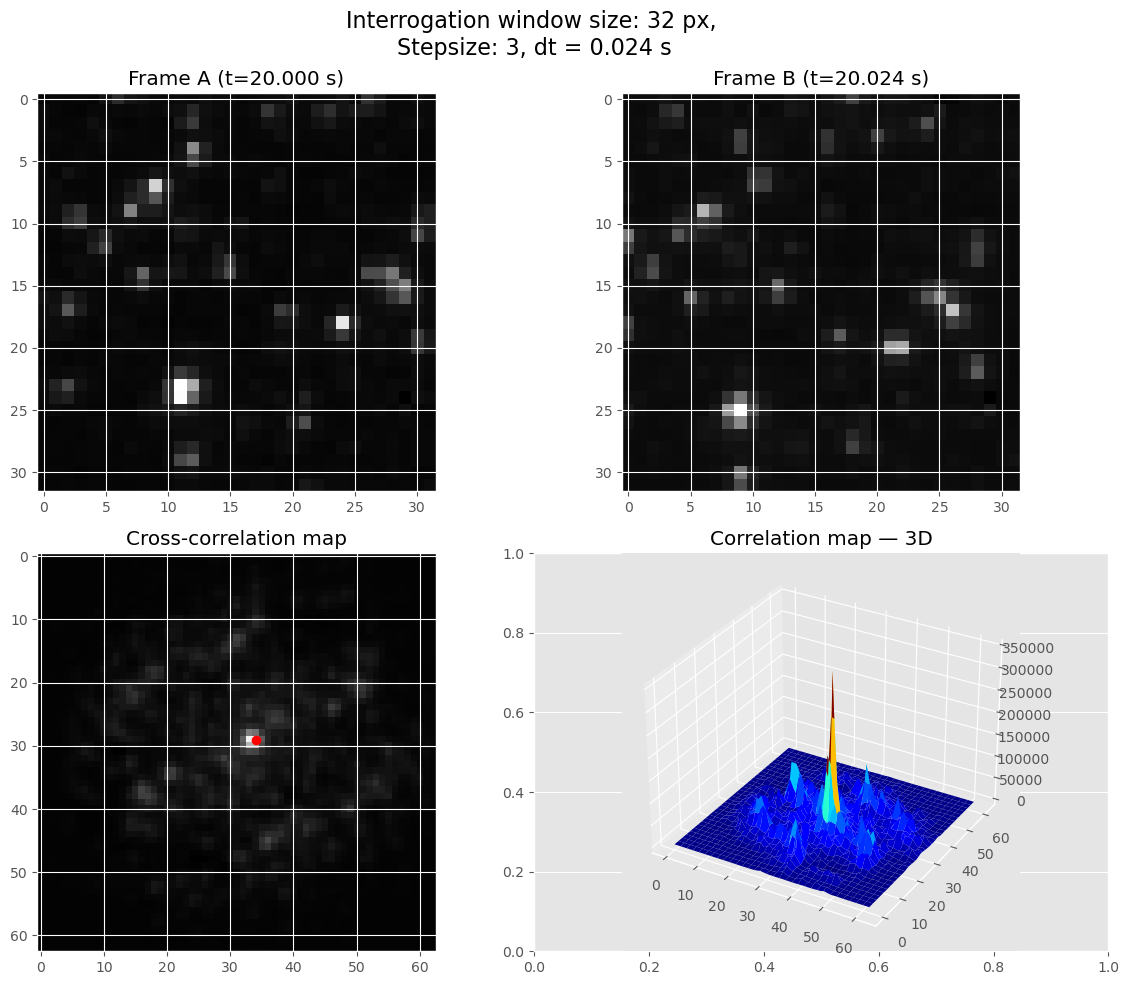

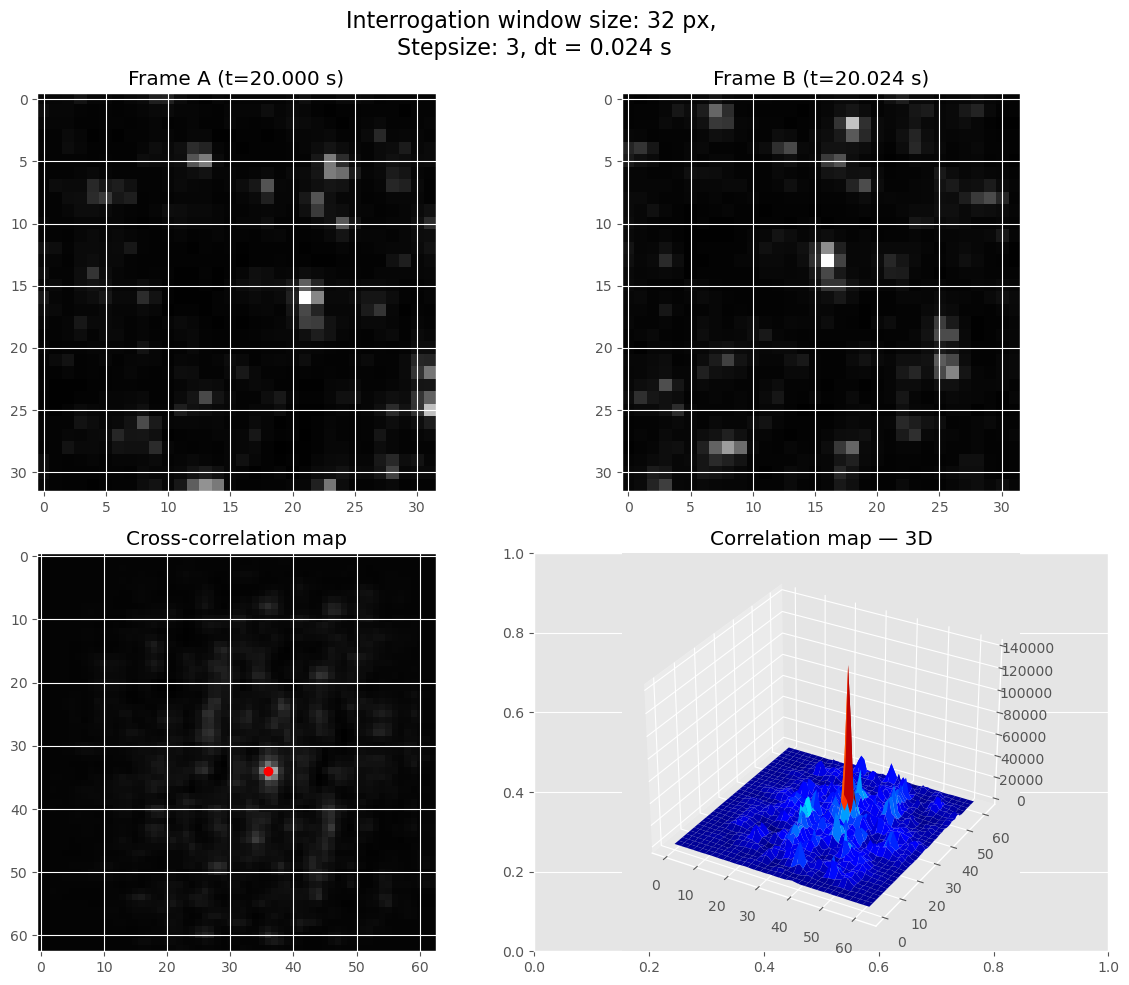

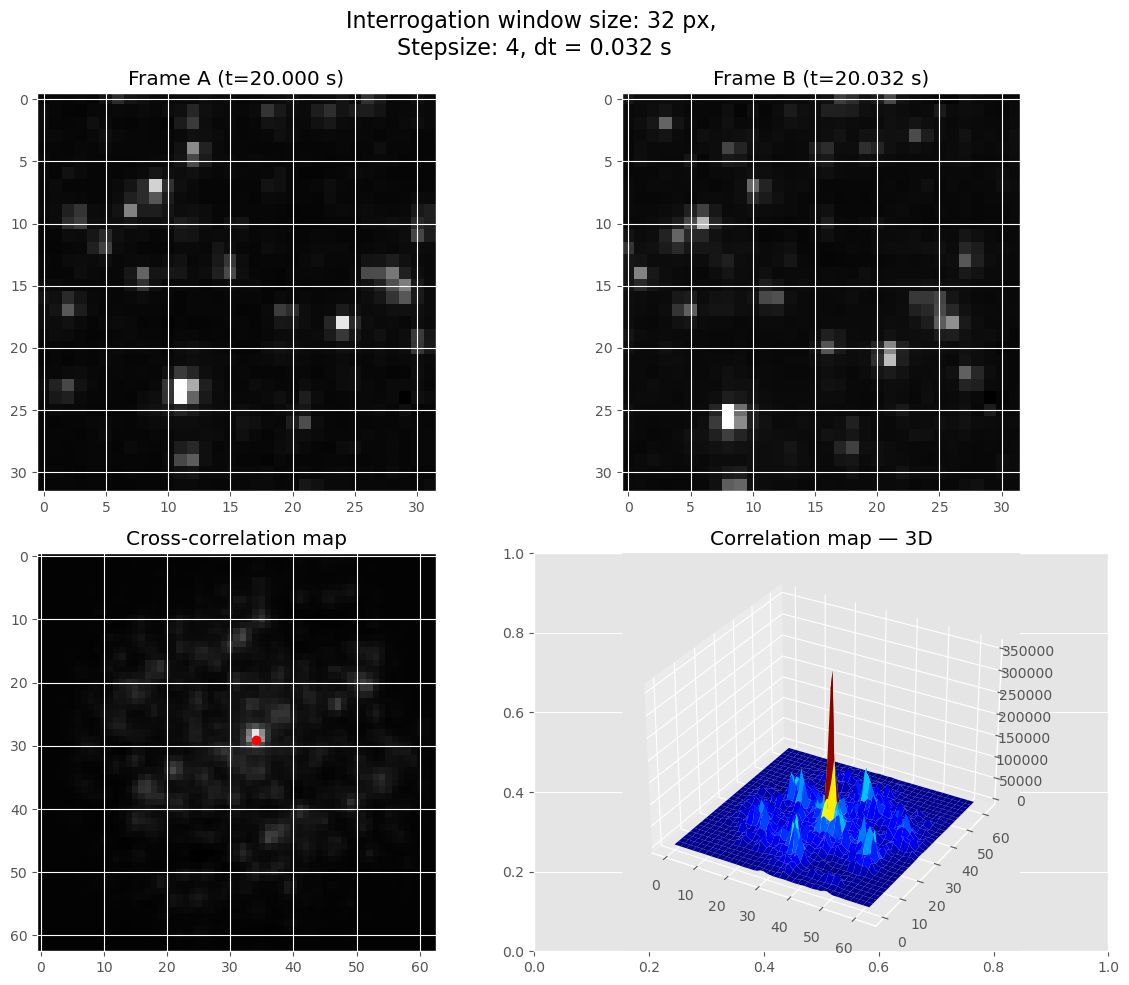

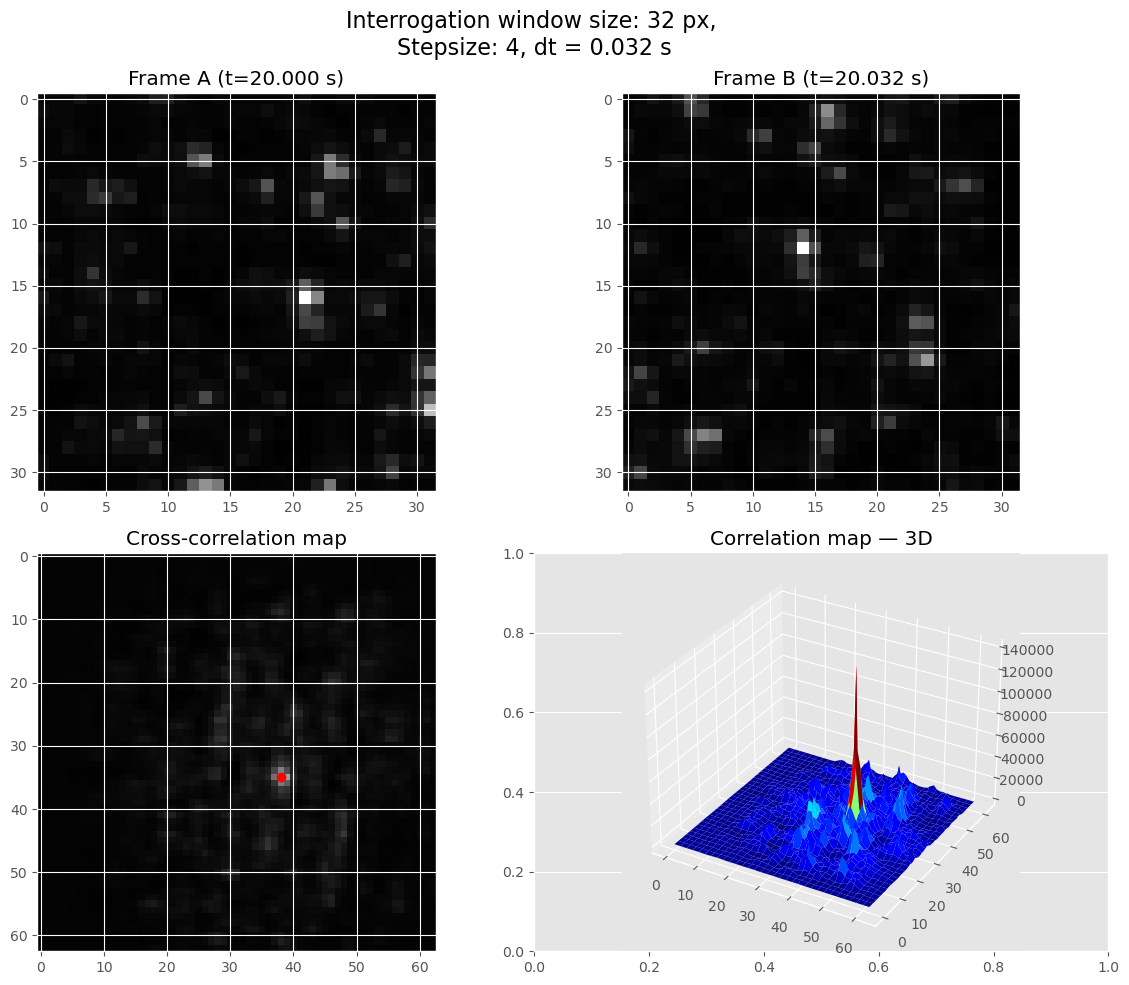

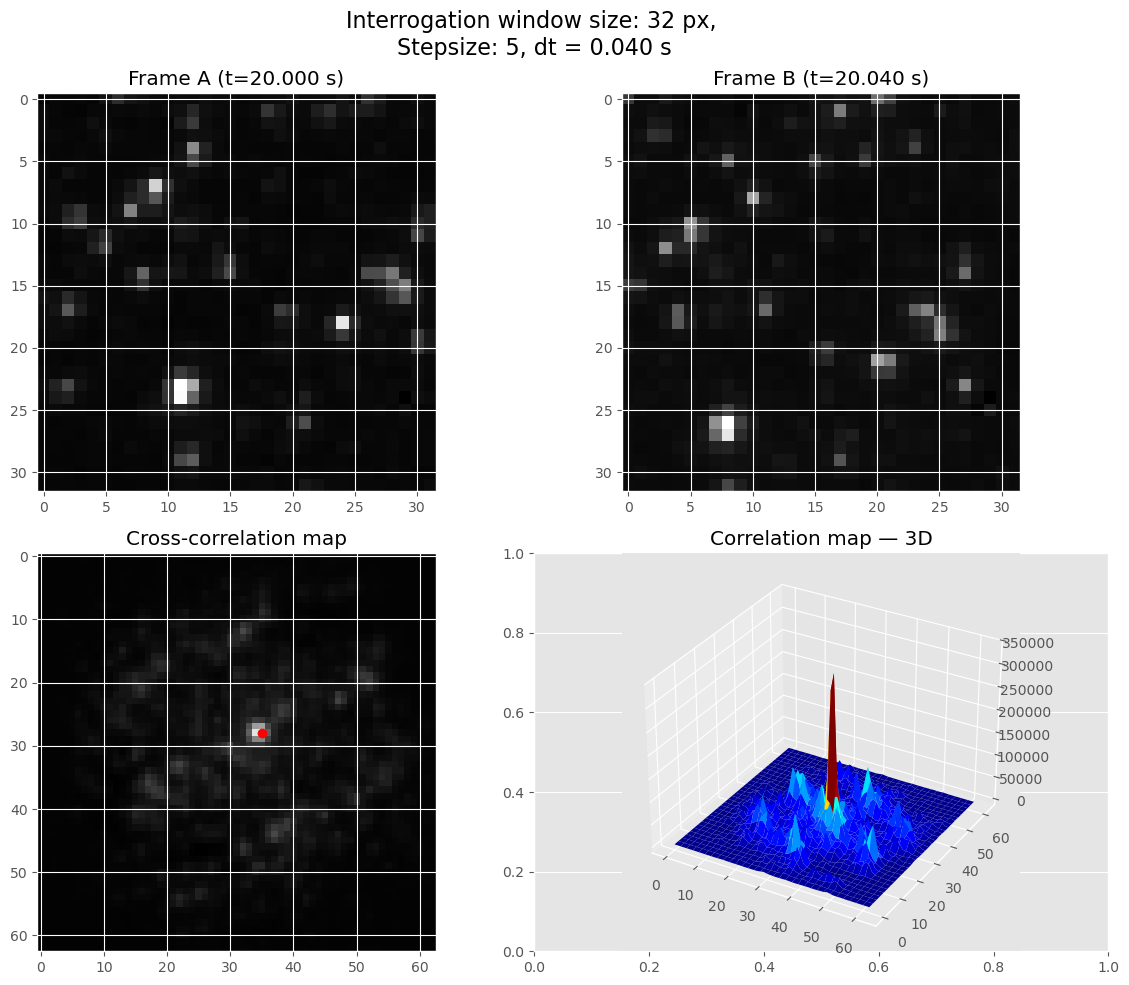

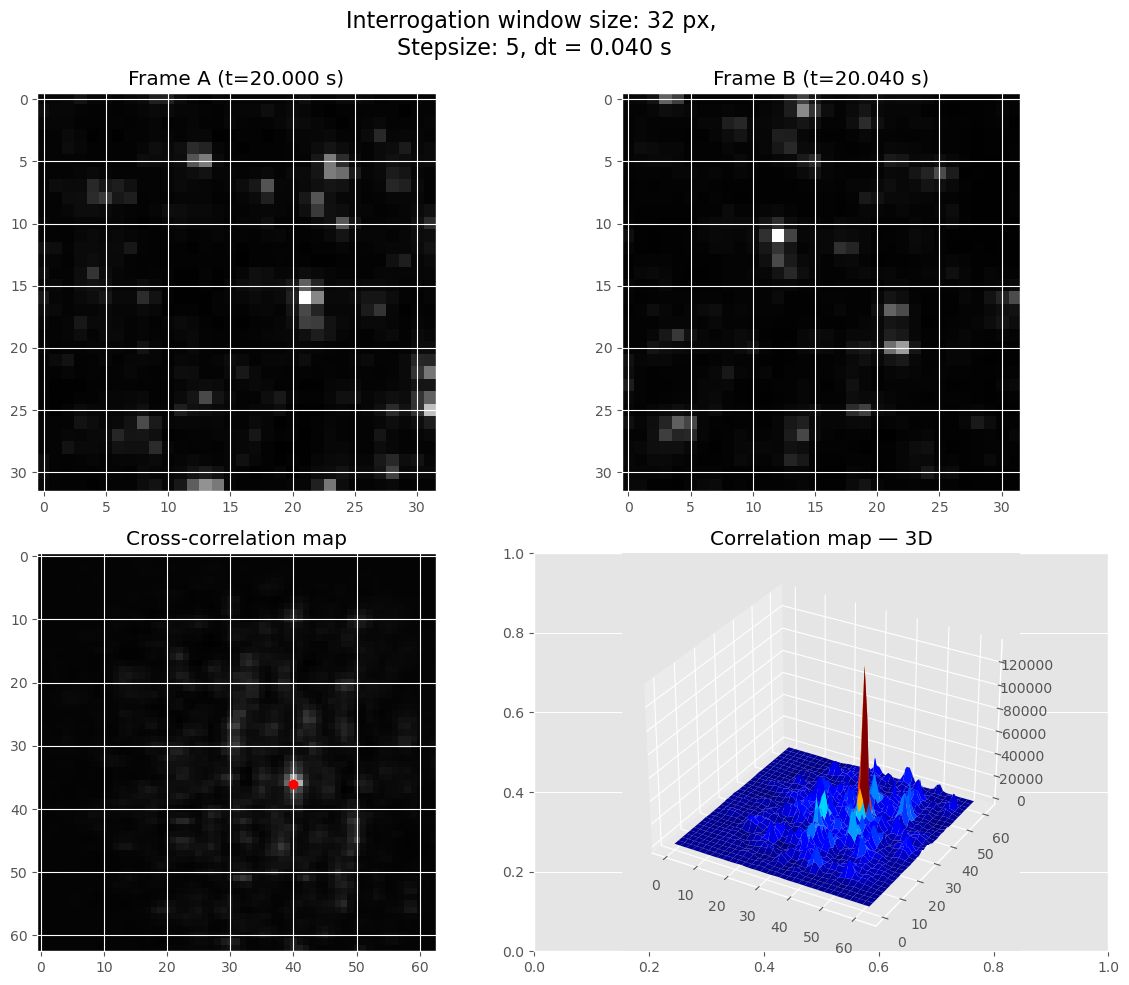

In [17]:
from scipy.signal import correlate
from mpl_toolkits.mplot3d import Axes3D
window_size = [32]
stepsize = [2, 3, 4, 5]

for w in window_size:
    for s in stepsize:
        print(f"Window size: {w} px, Stepsize: {s}")
        win_a = cleaned_frames[1250][-w:, -w:]
        win_b = cleaned_frames[1250 + s][-w:, -w:]
        frame_a = 1250
        frame_b = 1250 + s
        time_a = timestamps[0]
        time_b = timestamps[0+s]
        dt = time_b - time_a 
    
        cross_corr = correlate(win_a, win_b, mode='full')

        # Bottom right corner
        fig, ax = plt.subplots(2, 2, figsize=(12, 10))

        ax[0, 0].imshow(win_a, cmap='gray')
        ax[0, 0].set_title(f'Frame A (t={time_a:.3f} s)')

        ax[0, 1].imshow(win_b, cmap='gray')
        ax[0, 1].set_title(f'Frame B (t={time_b:.3f} s)')

        ax[1, 0].imshow(cross_corr, cmap='gray')
        ax[1, 0].set_title('Cross-correlation map')
        y, x = np.unravel_index(cross_corr.argmax(), cross_corr.shape)
        ax[1, 0].plot(x, y, "ro")

        # Create the 3D axis in the (2,2) grid, position 4 (row 2, col 2)
        ax_3d = fig.add_subplot(2, 2, 4, projection="3d")
        ax_3d.set_title('Correlation map — 3D')

        Y, X = np.meshgrid(
            np.arange(cross_corr.shape[0]),
            np.arange(cross_corr.shape[1]))
        ax_3d.plot_surface(Y, X, cross_corr, cmap='jet', linewidth=0.2)

        fig.suptitle(
        f"Interrogation window size: {w} px, \n"
        f"Stepsize: {s}, dt = {time_b - time_a:.3f} s", fontsize=16)
        plt.tight_layout()

        # top left corner
        win_a = cleaned_frames[1250][:w, :w]
        win_b = cleaned_frames[1250 + s][:w, :w]
        frame_a = 1250
        frame_b = 1250 + s
        time_a = timestamps[0]
        time_b = timestamps[0+s]
        dt = time_b - time_a 
    
        cross_corr = correlate(win_a, win_b, mode='full')
        fig, ax = plt.subplots(2, 2, figsize=(12, 10))

        ax[0, 0].imshow(win_a, cmap='gray')
        ax[0, 0].set_title(f'Frame A (t={time_a:.3f} s)')

        ax[0, 1].imshow(win_b, cmap='gray')
        ax[0, 1].set_title(f'Frame B (t={time_b:.3f} s)')

        ax[1, 0].imshow(cross_corr, cmap='gray')
        ax[1, 0].set_title('Cross-correlation map')
        y, x = np.unravel_index(cross_corr.argmax(), cross_corr.shape)
        ax[1, 0].plot(x, y, "ro")

        # Create the 3D axis in the (2,2) grid, position 4 (row 2, col 2)
        ax_3d = fig.add_subplot(2, 2, 4, projection="3d")
        ax_3d.set_title('Correlation map — 3D')

        Y, X = np.meshgrid(
            np.arange(cross_corr.shape[0]),
            np.arange(cross_corr.shape[1]))
        ax_3d.plot_surface(Y, X, cross_corr, cmap='jet', linewidth=0.2)

        fig.suptitle(
        f"Interrogation window size: {w} px, \n"
        f"Stepsize: {s}, dt = {time_b - time_a:.3f} s", fontsize=16)
        plt.tight_layout()

        print(f"Displacement (x, y): ({x - w + 1}, {y - w + 1}) pixels")

In [20]:
# PIV parameters

window_size = 32  # interrogation window size (in pixels)
overlap = window_size // 2 # overlap between interrogation windows (in pixels)
search_area_size = window_size  # search area size (in pixels)
stepsize = 4  # how many frames to skip between PIV analyses
threshold = 1.2  # sig2noise threshold for validation
max_iter = 10  
kernel_size = 2 

Total flagged fraction after all validations:  0.006578947368421052
Total flagged fraction after all validations:  0.006030701754385965


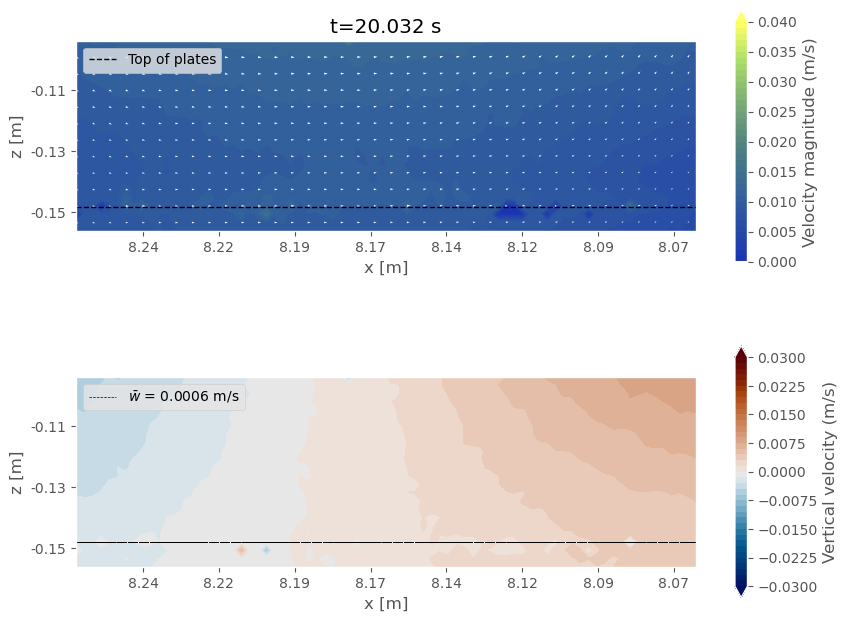

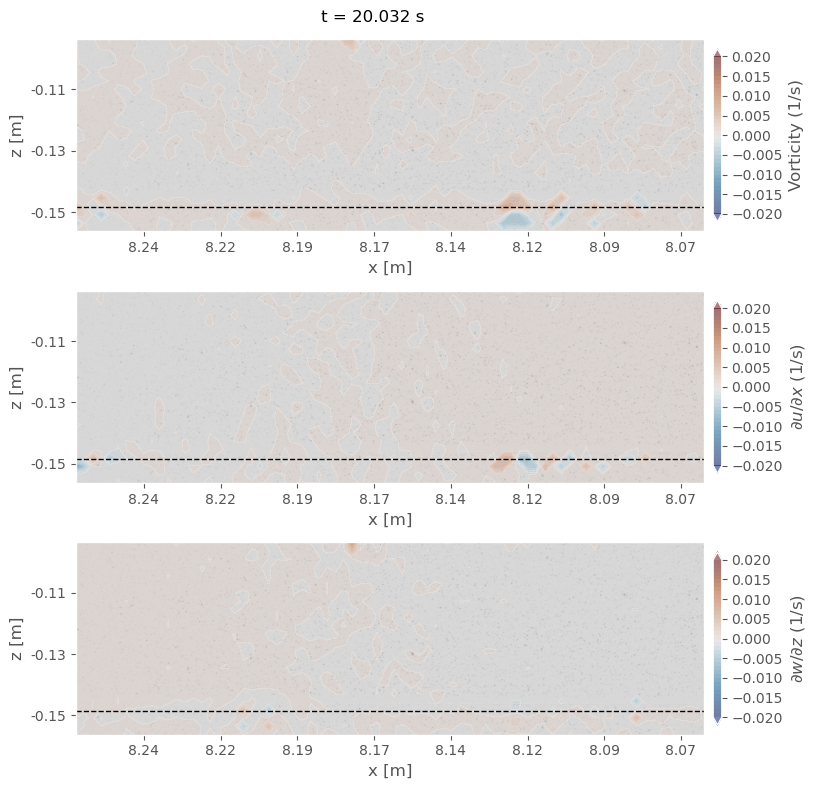

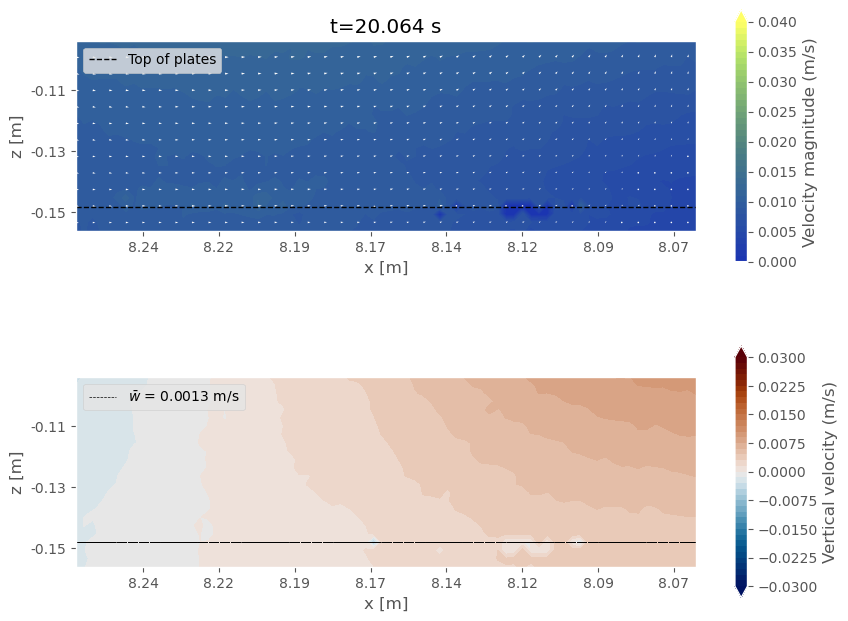

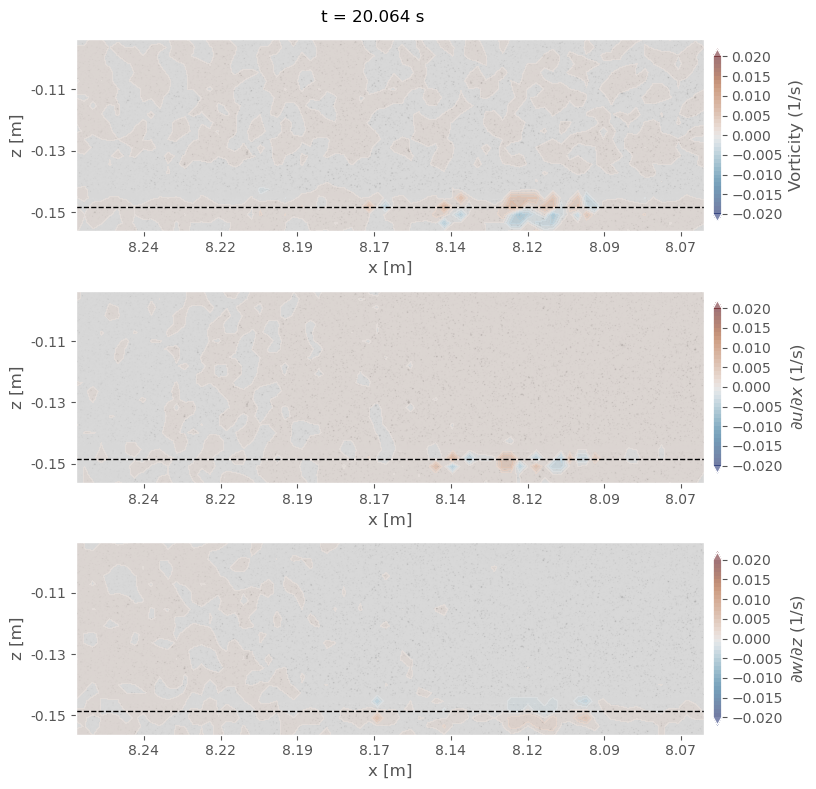

In [22]:
# Lists for storing vertical velocity
# and vertical velocity gradient around the plates 
times = []
x_top = None
W_list = []  # vertical velocity at plate top 
W_top_list = [] # vertical velocity one pixel above plate top 
W_under_list = [] # vertical velocity one pixel under plate top 
DW_list = [] # vertical velocity gradient at plate top 
DW_top_list = [] # vertical velocity gradient one pixel above plate top 
DW_under_list = [] # vertical velocity gradient one pixel under plate top 
flag_frac_list = [] # list of fraction of vectors flagged as outliers (for whole field, not just plate top)

#for key in range(1250, 1516-stepsize, stepsize):
for key in range(1250, 1256, stepsize):
    # Run PIV
    frame_a = cleaned_frames[key]
    frame_b = cleaned_frames[key + stepsize]
    
    # Time indices for the two frames used in PIV
    idx_a = key - 1250
    idx_b = idx_a + stepsize

    time_a = timestamps[idx_a]
    time_b = timestamps[idx_b]

    dt = time_b - time_a

    # Perform PIV analysis
    u, v, sig2noise = pyprocess.extended_search_area_piv(
    frame_a, frame_b,
    window_size=window_size,
    overlap=overlap,
    dt=dt*stepsize,
    search_area_size=search_area_size)

    # Get coordinates
    x, y = pyprocess.get_coordinates(
    image_size=frame_a.shape,
    search_area_size=search_area_size,
    overlap=overlap)

    # 1) Signal-to-noise validation
    u, v, mask = validation.sig2noise_val(u, v, sig2noise, threshold=threshold)
    
    # 2) Local median validation
    u, v, mask = validation.local_median_val(
    u, v, u_threshold=50, v_threshold=50)

    flag_frac = np.mean(mask)
    print("Total flagged fraction after all validations: ", flag_frac)

    # 3) Replace outliers by local mean
    u, v = filters.replace_outliers(
    u, v,
    method='localmean',
    max_iter=max_iter,
    kernel_size=kernel_size)

    # 4) Scale to physical units
    x, y, u, v = scaling.uniform(x, y, u, v, scaling_factor=scaling_factor) 

    # Calculate vorticity and velocity gradients
    curl_u = np.gradient(u, axis=0) # du/dz
    curl_w = np.gradient(v, axis=1) # dw/dx
    curl = curl_u - curl_w  # vorticity
    grad_u = np.gradient(u, axis=1) # du/dx
    grad_w = np.gradient(v, axis=0) # dw/dz

    # Find location of top of plates in physical units (m) and corresponding index in y array
    plate_top_m = plate_top_index/scaling_factor
    y_idx_plate_top = (np.abs(y[:, 0] - plate_top_m)).argmin()

    # Find vertical velocity in the region of the plates
    # Exact plate top
    w = np.asarray(v[y_idx_plate_top, :])
    dwdz = np.asarray(grad_w[y_idx_plate_top, :])
    no_w_vec = np.shape(v[y_idx_plate_top, :])
    # One pixel above plate top
    w_top = np.asarray(v[y_idx_plate_top - 1, :])
    dwdz_top = np.asarray(grad_w[y_idx_plate_top - 1, :])
    # One pixel under plate top
    w_under = np.asarray(v[y_idx_plate_top + 1, :])
    dwdz_under = np.asarray(grad_w[y_idx_plate_top + 1, :])

    # For plotting, mean vertical velocity at plate top to show in legend
    w_bar = np.mean(v[y_idx_plate_top, :])

    x_top_current = x[y_idx_plate_top, :]  # shape (Nx,)
    if x_top is None:
        x_top = x_top_current.copy()

    times.append(time_b)
    W_list.append(w)       # shape (Nx,)
    DW_list.append(dwdz)   # shape (Nx,)
    flag_frac_list.append(flag_frac)
    W_top_list.append(w_top)
    W_under_list.append(w_under)
    DW_top_list.append(dwdz_top)
    DW_under_list.append(dwdz_under)

    # ---------------
    # PLOTTING
    # ---------------
    # Origin (0,0) is at the top left corner of the cleaned image, 
    # meaning x increases to the right, y increases downwards
    # For plotting, I want to show the location in the tank, so I modify x to match location in the tank
    # and y to be negative and descending downwards to be depth

    x_max = x.max()
    y_min = y.min()

    # Plot the velocity field
    fig, ax = plt.subplots(2, 1, figsize=(10,8))

    ax[0].imshow(cleaned_frames[key+1], cmap='gray_r', alpha=0.5, extent=(x.min(), x.max(), y.max(), y.min()))
    ax[1].imshow(cleaned_frames[key+1], cmap='gray_r', alpha=0.5, extent=(x.min(), x.max(), y.max(), y.min()))

    # Colorbar limits for vertical velocity
    vmin = -0.03
    vmax = 0.03
    
    # Colorbar limits for velocity magnitude
    umin = 0
    umax = 0.04

    # Subsampling steps for quiver plot
    step_x = 2
    step_z = 2

    # Filled contour of velocity magnitude
    im = ax[0].contourf(x, y, np.sqrt(u**2 + v**2), cmap=cm.imola, levels=np.linspace(umin, umax, 41), extend='max')

    # Quiver plot of velocity vectors
    im1 = ax[0].quiver(x[::step_z, ::step_x], y[::step_z, ::step_x], -u[::step_z, ::step_x], v[::step_z, ::step_x], color='white', scale=2)
    cbar = plt.colorbar(im, label='Velocity magnitude (m/s)', shrink=0.9)

    ax[0].hlines(y=plate_top_m, xmin=x.min(), xmax=x.max(), colors='black', linestyles='--', linewidth=1, label='Top of plates')
    ax[0].set_title(f't={timestamps[idx_b]:.3f} s')
    ax[0].grid()
    ax[0].legend(loc='upper left')

    # Filled contour plot of vertical velocity
    im1 = ax[1].contourf(x, y, v, cmap=cm.vik, levels=np.linspace(vmin, vmax, 41), extend='both')

    cbar3 = plt.colorbar(
    im1, extend='both',
    label='Vertical velocity (m/s)', shrink=0.9)

    ax[1].grid()
    ax[1].hlines(
    y=y[y_idx_plate_top, :], xmin=x.min(), xmax=x.max(),
    colors='black', linewidth=0.5, linestyles='--',
    label=rf'$\bar w$ = {w_bar:.4f} m/s')

    ax[1].legend(loc='upper left')

    for a in ax:
        a.xaxis.set_major_formatter(FuncFormatter(x_phys_formatter))
        a.set_xlabel("x [m]")
        a.yaxis.set_major_formatter(FuncFormatter(depth_formatter))
        a.set_ylabel("z [m]")

    #plt.savefig(f'/Users/kjesta/Desktop/LABDATA/PIV/Results/zoom/figs/f14a03/vel_field_{key}_r3.png', dpi=100)
    #plt.close(fig)

    # Plot the vorticity and velocity gradients
    vmin = -0.02
    vmax = 0.02
    vlev = np.linspace(vmin, vmax, 41)

    umin = -0.02
    umax = 0.02
    ulev = np.linspace(umin, umax, 41)

    wmin = -0.02
    wmax = 0.02
    wlev = np.linspace(wmin, wmax, 41)

    # Vorticity
    fig, ax = plt.subplots(3, 1, figsize=(10,8))
    im = ax[0].contourf(x, y, curl, alpha=0.5, levels=vlev, cmap=cm.vik, extend='both')
    ax[0].imshow(cleaned_frames[key+1], cmap='gray_r', alpha=0.5,extent=(x.min(), x.max(), y.max(), y.min()))
    cbar = plt.colorbar(im, ax=ax[0], label='Vorticity (1/s)', pad=0.01, shrink=0.9)
    ax[0].grid()
    ax[0].hlines(y=plate_top_m, xmin=x.min(), xmax=x.max(), colors='black', linestyles='--', linewidth=1, label='Top of plates')

    # Velocity gradients
    im = ax[1].contourf(x, y, grad_u, alpha=0.5, levels=ulev, cmap=cm.vik, extend='both')
    cbar = plt.colorbar(im, ax=ax[1], label=r'$\partial u / \partial x$ (1/s)', pad=0.01, shrink=0.9)
    ax[1].imshow(cleaned_frames[key+1], cmap='gray_r', alpha=0.5, extent=(x.min(), x.max(), y.max(), y.min()))
    ax[1].grid()
    ax[1].hlines(y=plate_top_m, xmin=x.min(), xmax=x.max(), colors='black', linestyles='--', linewidth=1, label='Top of plates')

    im = ax[2].contourf(x, y, grad_w, alpha=0.5, levels=wlev, cmap=cm.vik, extend='both')
    cbar = plt.colorbar(im, ax=ax[2], label=r'$\partial w / \partial z$ (1/s)', pad=0.01, shrink=0.9)
    ax[2].imshow(cleaned_frames[key+1], cmap='gray_r', alpha=0.5, extent=(x.min(), x.max(), y.max(), y.min()))
    ax[2].grid()
    ax[2].hlines(y=plate_top_m, xmin=x.min(), xmax=x.max(), colors='black', linestyles='--', linewidth=1, label='Top of plates')
    fig.suptitle(f't = {timestamps[idx_b]:.3f} s')

    for a in ax:
        a.xaxis.set_major_formatter(FuncFormatter(x_phys_formatter))
        a.set_xlabel("x [m]")
        a.yaxis.set_major_formatter(FuncFormatter(depth_formatter))
        a.set_ylabel("z [m]")
        
    plt.tight_layout()  
    #plt.savefig(f'/Users/kjesta/Desktop/LABDATA/PIV/Results/zoom/figs/f14a03/curl_grad_{key}_r3.png', dpi=100)
    #plt.close(fig)

# Convert lists to arrays for saving
time = np.array(times)
W = np.vstack(W_list)      # shape (Nt, Nx)
DW = np.vstack(DW_list)    # shape (Nt, Nx)
W_top = np.vstack(W_top_list)      # shape (Nt, Nx)
W_under = np.vstack(W_under_list)      # shape (Nt, Nx)
DW_top = np.vstack(DW_top_list)    # shape (Nt, Nx)
DW_under = np.vstack(DW_under_list)    # shape (Nt, Nx)
flag_frac_arr = np.array(flag_frac_list)

# Create and save NetCDF
import xarray as xr
ds = xr.Dataset(
    data_vars=dict(
        w=(["time", "x"], W),
        dwdz=(["time", "x"], DW),
        w_top=(["time", "x"], W_top),
        w_under=(["time", "x"], W_under),
        dwdz_top=(["time", "x"], DW_top),
        dwdz_under=(["time", "x"], DW_under),
        flag_fraction=(["time"], flag_frac_arr),
    ),
    coords=dict(
        time=("time", time),
        x=("x", x_top),
    ),
    attrs=dict(
        description="PIV results along plate top",
        units_w="m s-1",
        units_dwdz="s-1",
    ),
)

#ds.to_netcdf('/Users/kjesta/Desktop/LABDATA/PIV/results/zoom/f14a03_zoom_res_r3.nc')